# Cardiovascular Disease — Exploratory Data Analysis (EDA)

**Dataset:** `cardio_train.csv` — 70,000 patient records, 13 columns.
This notebook is the EDA stage for the clinical intelligence system. The goal of EDA here is not just to "look at the data" but to answer four questions before any modelling:

1. **Structure** — what are the rows, columns, types, and grain of the data?
2. **Quality** — what is missing, duplicated, or *clinically impossible*?
3. **Distributions** — what does each variable look like on its own?
4. **Signal** — how does each variable relate to the target (`cardio`)?

> The `cardio_train.csv` columns and their meaning:
>
> | column | meaning | notes |
> |---|---|---|
> | `id` | record id | drop for analysis |
> | `age` | age **in days** | convert to years |
> | `gender` | 1 = women, 2 = men | categorical |
> | `height` | height in cm | |
> | `weight` | weight in kg | |
> | `ap_hi` | systolic BP | **known to contain bad values** |
> | `ap_lo` | diastolic BP | **known to contain bad values** |
> | `cholesterol` | 1 normal, 2 above, 3 well above | ordinal |
> | `gluc` | glucose: 1 normal, 2 above, 3 well above | ordinal |
> | `smoke` | smoker (0/1) | binary |
> | `alco` | alcohol intake (0/1) | binary |
> | `active` | physically active (0/1) | binary |
> | `cardio` | **target** — has CVD (0/1) | binary |


## 1. Setup

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

RANDOM_STATE = 42

## 2. Load the data

This file is **semicolon-separated** (`;`), which is a classic gotcha — read it with a comma and you get one giant column. The loader below tries `;` first and falls back to `,`, so it is robust to either.

Point `DATA_PATH` at wherever your file lives.

In [10]:
DATA_PATH = "../data/raw/cardio_train.csv"   # e.g. "/mnt/user-data/uploads/cardio_train.csv"

def load_cardio(path):
    df = pd.read_csv(path, sep=";")
    if df.shape[1] == 1:                 # wrong delimiter -> fell into one column
        df = pd.read_csv(path, sep=",")
    return df

df = load_cardio(DATA_PATH)
print(f"Loaded shape: {df.shape}")
df.head()


Loaded shape: (70000, 13)


/Users/cosmina/Ginger_Gradient/clinical-intelligence-system/.venv/lib/python3.11/site-packages/IPython/core/formatters.py:406: FutureWarning: Index.format is deprecated and will be removed in a future version. Convert using index.astype(str) or index.map(formatter) instead.
  return method()
/Users/cosmina/Ginger_Gradient/clinical-intelligence-system/.venv/lib/python3.11/site-packages/IPython/core/formatters.py:406: FutureWarning: RangeIndex.format is deprecated and will be removed in a future version. Convert using index.astype(str) or index.map(formatter) instead.
  return method()


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


## 3. Structure: shape, types, and a first look

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [12]:
# Tail too — sometimes junk hides at the end of a file
df.tail()

/Users/cosmina/Ginger_Gradient/clinical-intelligence-system/.venv/lib/python3.11/site-packages/IPython/core/formatters.py:406: FutureWarning: Index.format is deprecated and will be removed in a future version. Convert using index.astype(str) or index.map(formatter) instead.
  return method()
/Users/cosmina/Ginger_Gradient/clinical-intelligence-system/.venv/lib/python3.11/site-packages/IPython/core/formatters.py:406: FutureWarning: RangeIndex.format is deprecated and will be removed in a future version. Convert using index.astype(str) or index.map(formatter) instead.
  return method()


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1
69999,99999,20540,1,170,72.0,120,80,2,1,0,0,1,0


In [13]:
# Numeric summary. 'age' is in days, so the numbers look odd until we convert.
df.describe().T

/Users/cosmina/Ginger_Gradient/clinical-intelligence-system/.venv/lib/python3.11/site-packages/IPython/core/formatters.py:406: FutureWarning: Index.format is deprecated and will be removed in a future version. Convert using index.astype(str) or index.map(formatter) instead.
  return method()


,count,mean,std,min,25%,50%,75%,max
id,70000.0,49972.419900,28851.302323,0.0,25006.75,50001.5,74889.25,99999.0
age,70000.0,19468.865814,2467.251667,10798.0,17664.00,19703.0,21327.00,23713.0
gender,70000.0,1.349571,0.476838,1.0,1.00,1.0,2.00,2.0
height,70000.0,164.359229,8.210126,55.0,159.00,165.0,170.00,250.0
weight,70000.0,74.205690,14.395757,10.0,65.00,72.0,82.00,200.0
ap_hi,70000.0,128.817286,154.011419,-150.0,120.00,120.0,140.00,16020.0
ap_lo,70000.0,96.630414,188.472530,-70.0,80.00,80.0,90.00,11000.0
cholesterol,70000.0,1.366871,0.680250,1.0,1.00,1.0,2.00,3.0
gluc,70000.0,1.226457,0.572270,1.0,1.00,1.0,1.00,3.0
smoke,70000.0,0.088129,0.283484,0.0,0.00,0.0,0.00,1.0


### Read the `describe()` output like a clinician, not a statistician

Even before plotting, scan the `min`/`max` rows for **physically impossible values**:

- `ap_hi` (systolic) and `ap_lo` (diastolic) will show absurd min/max (negative numbers, values in the thousands). Real BP roughly lives in 60–250 (systolic) and 40–200 (diastolic) mmHg.
- `height` min/max may include people ~50 cm or ~250 cm.
- `weight` may include values near 0 or implausibly high.

These are the headline data-quality problems in this dataset, and EDA's job is to surface them.

## 4. Data quality checks

In [14]:
# 4a. Missing values
missing = df.isna().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() else "None")

Missing values per column:
None


In [15]:
# 4b. Duplicates. 'id' should be unique; full-row duplicates would be a red flag.
print("Duplicate ids        :", df["id"].duplicated().sum())
print("Fully duplicated rows:", df.drop(columns="id").duplicated().sum())

Duplicate ids        : 0
Fully duplicated rows: 24


In [16]:
# Drop the id column for analysis — it carries no signal.
df = df.drop(columns="id")

## 5. Feature engineering for interpretability

Three transforms make the data readable: age in years, BMI, and decoded category labels. We keep the raw columns and add readable companions.

In [ ]:
# Age: days -> years
df["age_years"] = (df["age"] / 365.25).round(1)

# BMI = kg / m^2
df["bmi"] = (df["weight"] / (df["height"] / 100) ** 2).round(1)

# Human-readable label maps (for plotting only; keep numeric cols for modelling)
gender_map = {1: "women", 2: "men"}
level_map  = {1: "normal", 2: "above normal", 3: "well above normal"}
binary_map = {0: "no", 1: "yes"}

df["gender_lbl"]      = df["gender"].map(gender_map)
df["cholesterol_lbl"] = df["cholesterol"].map(level_map)
df["gluc_lbl"]        = df["gluc"].map(level_map)
df[["age_years", "bmi", "gender_lbl", "cholesterol_lbl"]].head()

#df.head()

/Users/cosmina/Ginger_Gradient/clinical-intelligence-system/.venv/lib/python3.11/site-packages/IPython/core/formatters.py:406: FutureWarning: Index.format is deprecated and will be removed in a future version. Convert using index.astype(str) or index.map(formatter) instead.
  return method()
/Users/cosmina/Ginger_Gradient/clinical-intelligence-system/.venv/lib/python3.11/site-packages/IPython/core/formatters.py:406: FutureWarning: RangeIndex.format is deprecated and will be removed in a future version. Convert using index.astype(str) or index.map(formatter) instead.
  return method()


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi,gender_lbl,cholesterol_lbl,gluc_lbl
0,18393,2,168,62.0,110,80,1,1,0,0,1,0,50.4,22.0,men,normal,normal
1,20228,1,156,85.0,140,90,3,1,0,0,1,1,55.4,34.9,women,well above normal,normal
2,18857,1,165,64.0,130,70,3,1,0,0,0,1,51.6,23.5,women,well above normal,normal
3,17623,2,169,82.0,150,100,1,1,0,0,1,1,48.2,28.7,men,normal,normal
4,17474,1,156,56.0,100,60,1,1,0,0,0,0,47.8,23.0,women,normal,normal


## 6. Univariate analysis — one variable at a time

### 6a. Continuous variables

/Users/cosmina/Ginger_Gradient/clinical-intelligence-system/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/cosmina/Ginger_Gradient/clinical-intelligence-system/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/cosmina/Ginger_Gradient/clinical-intelligence-system/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/cosmina/Ginger_Gradient/clinical-intell

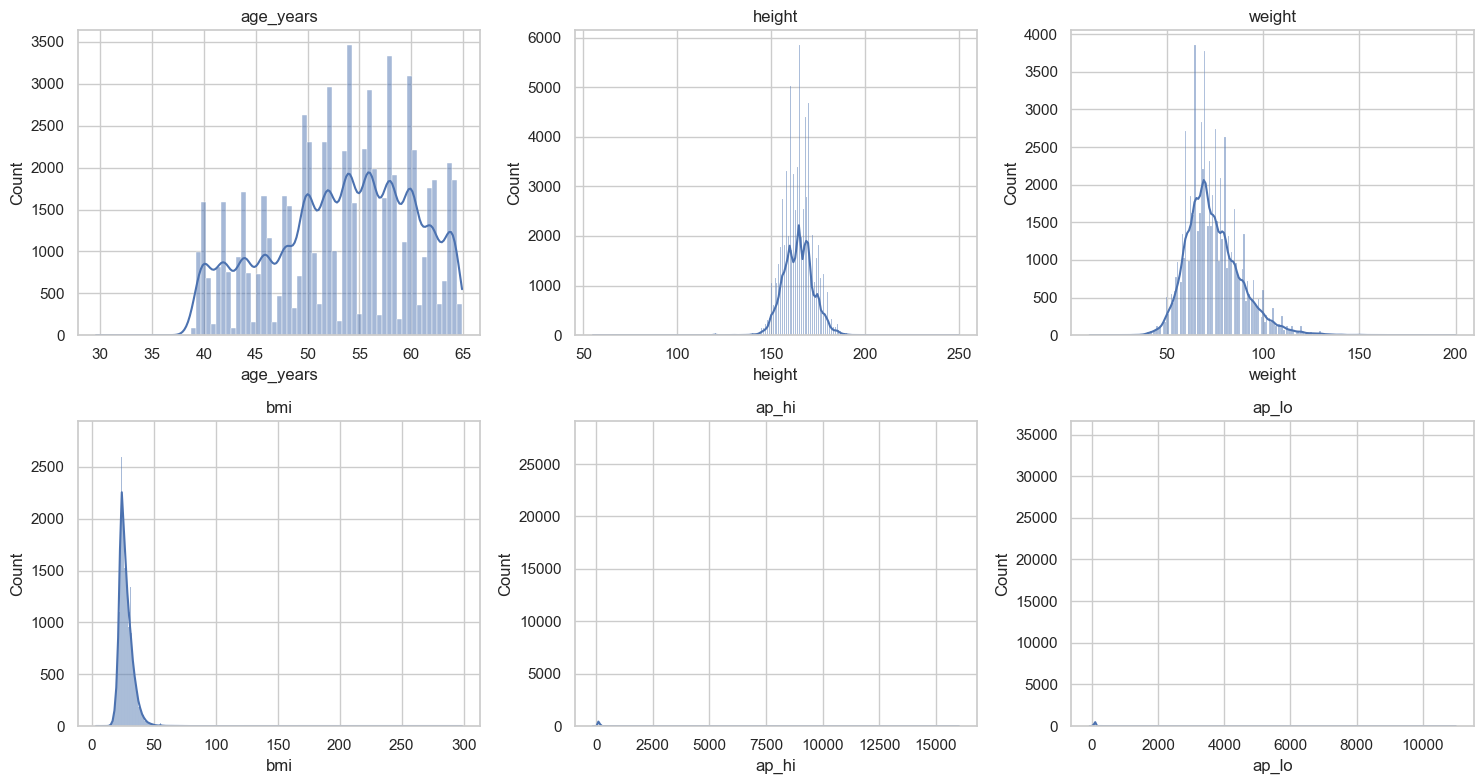

In [19]:
continuous = ["age_years", "height", "weight", "bmi", "ap_hi", "ap_lo"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), continuous):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

Note how `ap_hi` and `ap_lo` are almost unreadable — a handful of extreme values stretch the x-axis so the real distribution collapses into one bar. That *is* the finding: the BP columns are contaminated with bad data.

### 6b. Categorical / binary variables

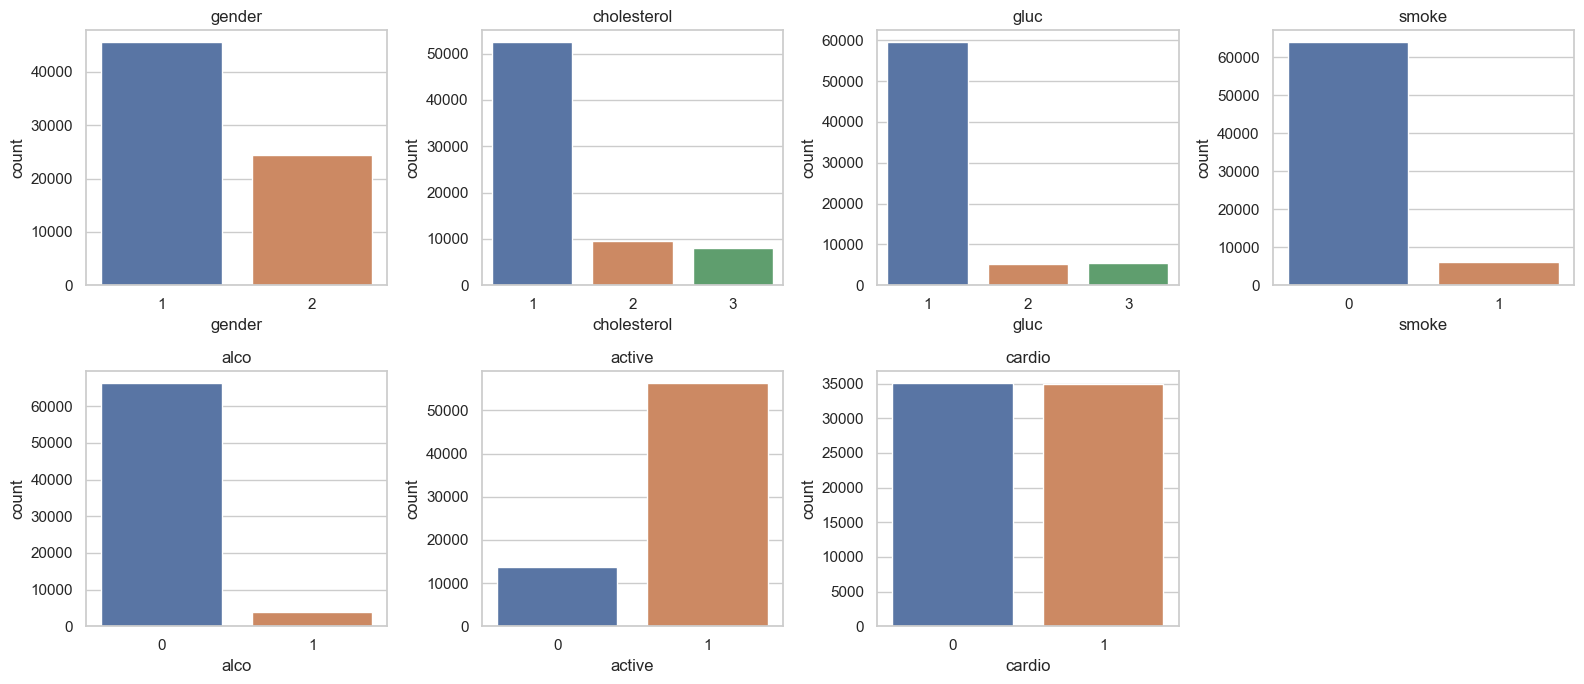

cardio
0    0.5
1    0.5
Name: proportion, dtype: float64


In [20]:
categorical = ["gender", "cholesterol", "gluc", "smoke", "alco", "active", "cardio"]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.ravel(), categorical):
    sns.countplot(x=col, data=df, ax=ax)
    ax.set_title(col)
for ax in axes.ravel()[len(categorical):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

# Target balance — important to know before modelling
print(df["cardio"].value_counts(normalize=True).round(3))

The target `cardio` is close to a 50/50 split, so accuracy is a reasonable baseline metric and no heavy class re-balancing is needed.

## 7. Clinical sanity checks — the heart of this EDA

This is where a clinical dataset differs from a generic one. We flag rows that are **physiologically impossible**, not just statistically extreme.

In [21]:
# Diastolic should never exceed systolic
bp_inverted = (df["ap_lo"] > df["ap_hi"]).sum()

# Plausible physiological ranges
out_of_range = {
    "ap_hi out of 60-250"   : (~df["ap_hi"].between(60, 250)).sum(),
    "ap_lo out of 40-200"   : (~df["ap_lo"].between(40, 200)).sum(),
    "height out of 120-220" : (~df["height"].between(120, 220)).sum(),
    "weight out of 30-200"  : (~df["weight"].between(30, 200)).sum(),
    "bmi out of 10-60"      : (~df["bmi"].between(10, 60)).sum(),
}

print(f"Rows with diastolic > systolic: {bp_inverted}")
for k, v in out_of_range.items():
    print(f"{k:24s}: {v}")

Rows with diastolic > systolic: 1234
ap_hi out of 60-250     : 228
ap_lo out of 40-200     : 1012
height out of 120-220   : 53
weight out of 30-200    : 7
bmi out of 10-60        : 71


In [22]:
# How extreme? Look at the raw BP range before cleaning.
print("ap_hi range:", df["ap_hi"].min(), "to", df["ap_hi"].max())
print("ap_lo range:", df["ap_lo"].min(), "to", df["ap_lo"].max())

ap_hi range: -150 to 16020
ap_lo range: -70 to 11000


### Apply clinically plausible filters

We build a clean copy rather than mutating in place, and report how many rows we lose. Keep the thresholds visible and easy to tune — they are clinical assumptions, not magic numbers.

In [23]:
before = len(df)
clean = df[
    df["ap_hi"].between(60, 250) &
    df["ap_lo"].between(40, 200) &
    (df["ap_hi"] >= df["ap_lo"]) &
    df["height"].between(120, 220) &
    df["weight"].between(30, 200) &
    df["bmi"].between(10, 60)
].copy()

print(f"Rows before: {before}")
print(f"Rows after : {len(clean)}  ({before - len(clean)} removed, "
      f"{(before - len(clean)) / before:.1%})")

Rows before: 70000
Rows after : 68595  (1405 removed, 2.0%)


/Users/cosmina/Ginger_Gradient/clinical-intelligence-system/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/cosmina/Ginger_Gradient/clinical-intelligence-system/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


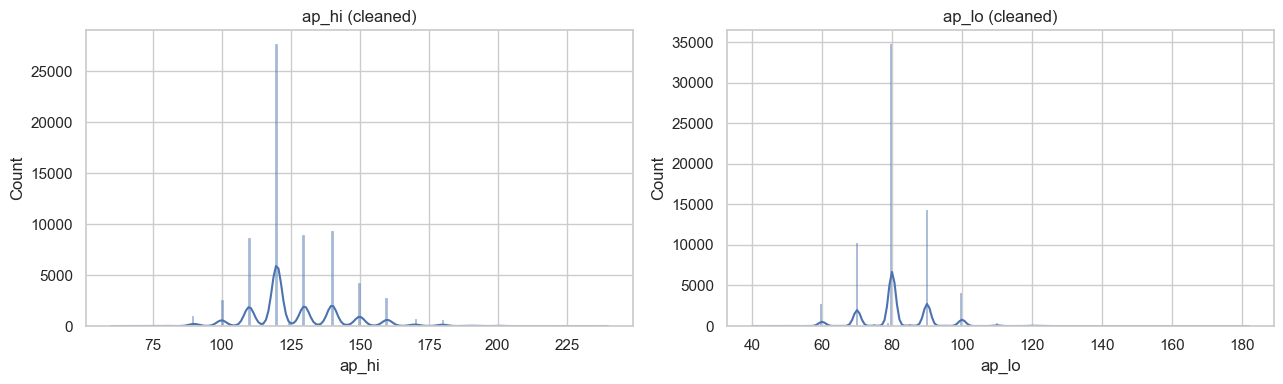

In [24]:
# Re-plot BP now that the impossible values are gone — distributions become legible.
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(clean["ap_hi"], kde=True, ax=axes[0]).set_title("ap_hi (cleaned)")
sns.histplot(clean["ap_lo"], kde=True, ax=axes[1]).set_title("ap_lo (cleaned)")
plt.tight_layout()
plt.show()

## 8. Bivariate analysis — relationship to the target `cardio`

### 8a. Continuous features vs. target

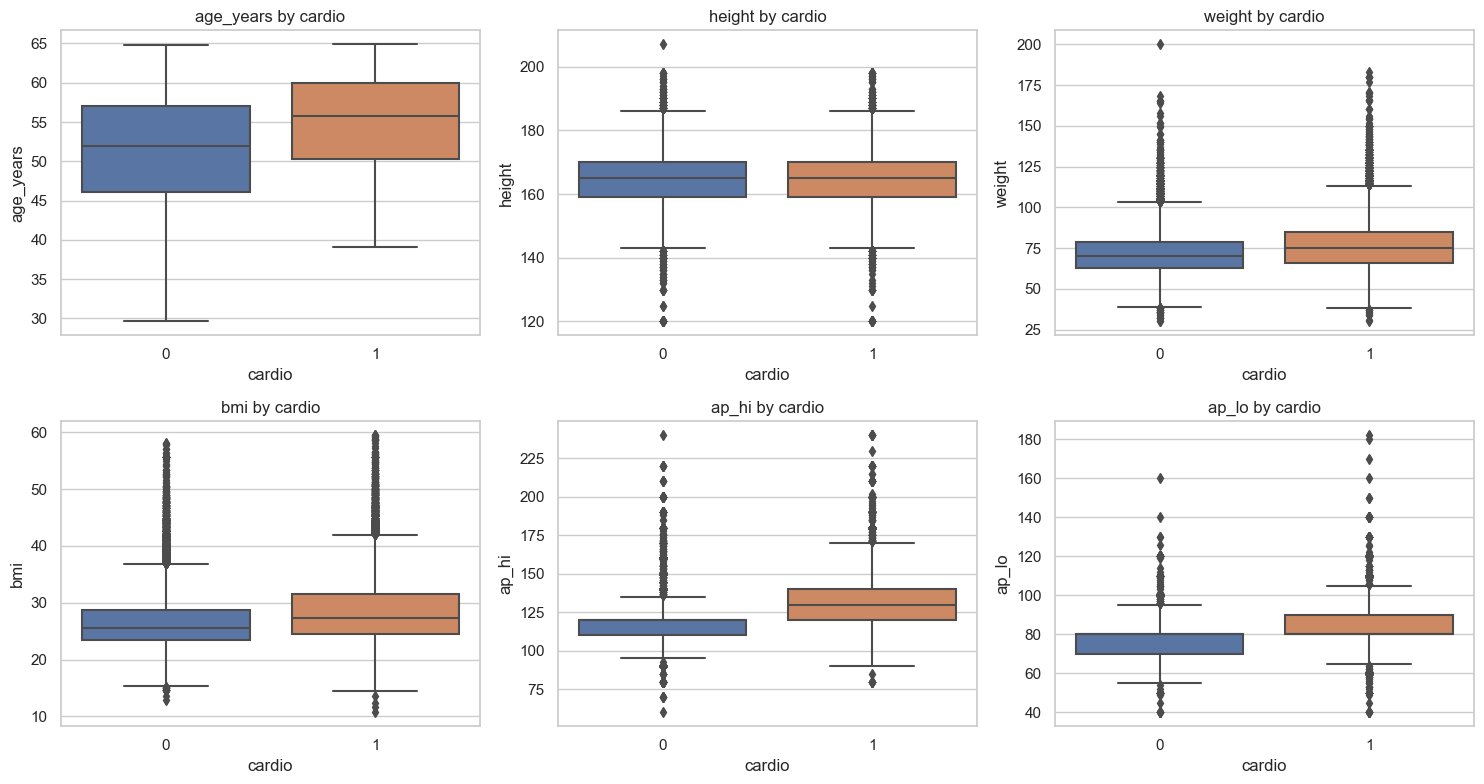

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), ["age_years", "height", "weight", "bmi", "ap_hi", "ap_lo"]):
    sns.boxplot(x="cardio", y=col, data=clean, ax=ax)
    ax.set_title(f"{col} by cardio")
plt.tight_layout()
plt.show()

Expect clear upward shifts for **age**, **systolic BP**, and **BMI** in the `cardio = 1` group — these are the strongest individual predictors and align with clinical intuition.

### 8b. Categorical features vs. target (CVD rate within each group)

ImportError: matplotlib is required for plotting when the default backend "matplotlib" is selected.

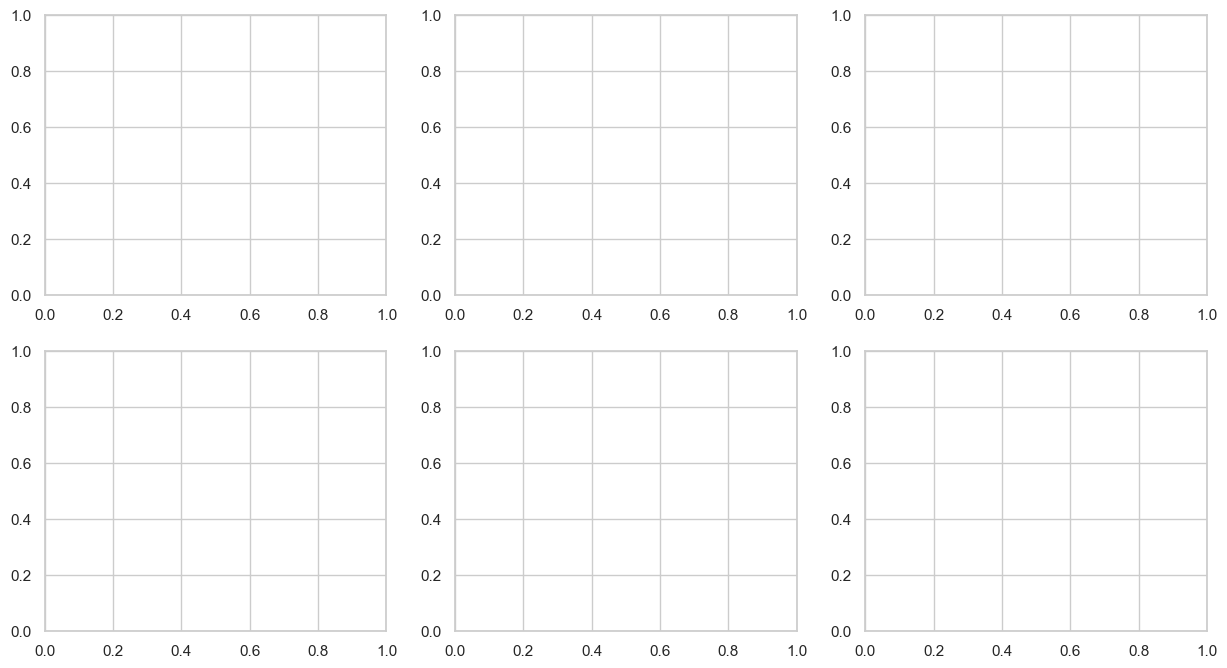

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
cat_cols = ["gender", "cholesterol", "gluc", "smoke", "alco", "active"]
for ax, col in zip(axes.ravel(), cat_cols):
    (clean.groupby(col)["cardio"].mean()
          .plot(kind="bar", ax=ax))
    ax.set_title(f"CVD rate by {col}")
    ax.set_ylabel("P(cardio=1)")
    ax.axhline(clean["cardio"].mean(), ls="--", color="k", lw=1)
plt.tight_layout()
plt.show()

The dashed line is the overall CVD rate. Bars well above it (e.g. high `cholesterol`, high `gluc`) flag higher-risk groups; `active = 1` should sit below the line.

## 9. Correlation structure

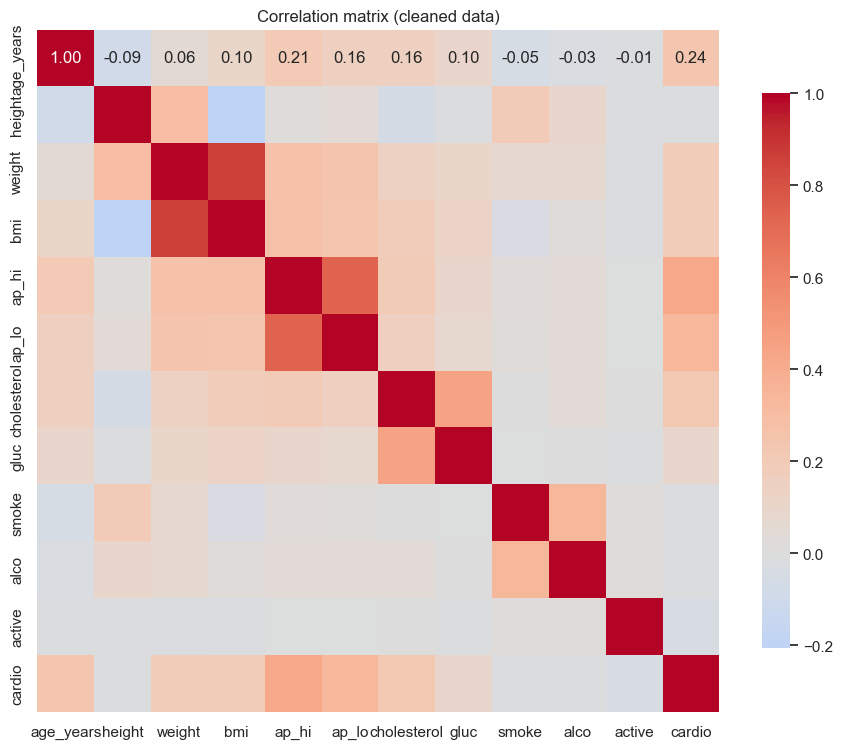

ap_hi          0.428035
ap_lo          0.340080
age_years      0.239476
cholesterol    0.221449
bmi            0.191294
weight         0.181035
gluc           0.089567
alco          -0.008448
height        -0.011704
smoke         -0.016268
active        -0.037703
Name: cardio, dtype: float64


In [29]:
num_cols = ["age_years", "height", "weight", "bmi",
            "ap_hi", "ap_lo", "cholesterol", "gluc",
            "smoke", "alco", "active", "cardio"]

corr = clean[num_cols].corr()
plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, cbar_kws={"shrink": .8})
plt.title("Correlation matrix (cleaned data)")
plt.show()

# Strongest linear associations with the target
print(corr["cardio"].drop("cardio").sort_values(ascending=False))

`ap_hi` and `ap_lo` will be strongly correlated with each other (multicollinearity to keep in mind for linear models). Against the target, `ap_hi`, `age_years`, and `cholesterol` typically lead.

## 10. Summary & handoff to the pipeline

**Structure.** 70k rows, 13 columns, one row per patient. `id` dropped; `age` converted to years; `bmi` engineered.

**Quality findings.**
- No missing values; check duplicates as shown.
- `ap_hi` / `ap_lo` contain impossible values (negatives, thousands, diastolic > systolic) — the dominant quality issue.
- Minor height/weight/BMI outliers.

**Cleaning rule applied** (tune thresholds with clinical input):
`ap_hi ∈ [60,250]`, `ap_lo ∈ [40,200]`, `ap_hi ≥ ap_lo`, `height ∈ [120,220]`, `weight ∈ [30,200]`, `bmi ∈ [10,60]`.

**Signal.** Target ~balanced. Strongest individual predictors: systolic BP, age, cholesterol, BMI. `active` is protective.

**Next steps for the system:** persist the cleaned frame, encode the ordinal (`cholesterol`, `gluc`) and binary features, watch ap_hi/ap_lo multicollinearity, then move to baseline modelling.

In [30]:
# Persist the cleaned dataset for the next pipeline stage
clean.to_csv("cardio_clean.csv", index=False)
print("Saved cardio_clean.csv:", clean.shape)

AttributeError: 'Index' object has no attribute '_format_native_types'